# Ridge regularization and estimator health

Live Plan 12 lab notebook. Every displayed result is loaded from validated, immutable artifacts. Partial views diagnose progression and do not unlock fixed-size inference.


## Reader's glossary

- **Gauge:** the 25 parameter directions that add the same value to every class logit and therefore leave softmax probabilities and NLL unchanged. The gauge-fixed chart removes them.
- **$s=\operatorname{tr}(\widehat F)/487$:** mean Fisher eigenvalue in the identifiable chart. $\kappa/s$ expresses ridge strength in dimensionless average-curvature units.
- **Top-eight trace fraction:** the fraction of total nonnegative Fisher trace carried by its eight largest eigenvalues.
- **$U_{8,t}$:** the predictable resolved basis derived from the archived Fisher before the current batch update. The archive is represented as $\widehat F_t=A_tA_t^T+\operatorname{diag}(d_t)$, where $A_t$ is the deterministic Lanczos-derived factor with at most eight columns. A reduced QR factorization $A_t=U_{8,t}T_t$ orthonormalizes its span; columns whose corresponding $|T_{t,jj}|$ is below the floating-point rank tolerance are removed. Thus $U_{8,t}$ spans the archive's rank-eight component, but is not an exact dense eigendecomposition of the full low-rank-plus-diagonal matrix.
- **Fixed-anchor batch variance:** estimator variance across independent four-example branch batches, holding the pretrained anchor state fixed, then averaged over anchors.
- **Isotropic ridge:** $\widehat F+\kappa I$. **Tail ridge:** $\widehat F+\kappa(I-U_8U_8^T)$, leaving the leading eight directions unpenalized by the added ridge.
- **Spectral selector:** the isotropic ridge value frozen from the median empirical 99th-percentile unresolved-spectrum maximum across eight checkpoints. It failed the calibration contract.
- **Tail-spectrum edge diagnostic:** a comparison of empirical resampled maxima after projecting out the leading eight directions with a deformed-MP upper edge. It is not prediction calibration.
- **Pooled recommendation variance:** variance of all shadow $\widehat\pi^\star$ recommendations pooled across steps and replicas. It mixes temporal and between-replica variation.
- **PIT:** the empirical CDF of resampled pseudo-tail maxima evaluated at a held-out observed maximum. Calibrated PIT values should be approximately uniform, with mean $.5$ under independence.


## Execution health


phase  planned  completed  pending  incomplete  failed  compute_h
phase0       7          7        0           0       0       0.03
phase1    4236       4236        0           0       0       0.41
phase2     705        705        0           0       0      10.92
phase3       9          9        0           0       0       0.00
phase4     577        577        0           0       0       8.50
phase5      33         33        0           0       0       0.36



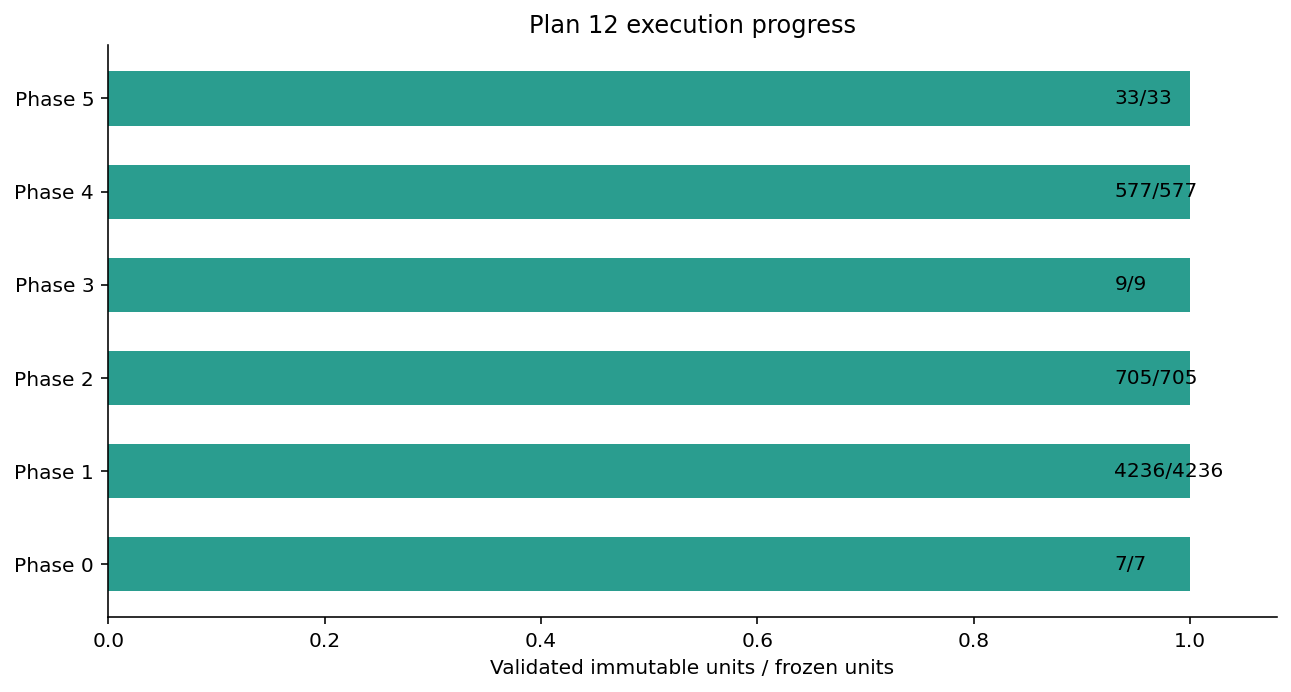

In [ ]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
PROGRESS = Path('/home/evan/Documents/notebooks/amari-chenstov-updates/cache/mnist_experiment/rotated_mnist/plan12_mp_q01_v1/reports/progress.json')
report = json.loads(PROGRESS.read_text(encoding='utf-8'))

print(report['interpretation'])
print(report['phase_progress'])


## Identifiability and measured cost


{
  "historical_audit": {
    "candidate_count": 1708,
    "selected_count": 48,
    "valid_count": 48,
    "aggregate": {
      "effective_rank": {
        "maximum": 43.925974236251136,
        "mean": 24.5584169098947,
        "median": 23.667928869050172,
        "minimum": 6.6153860476644075
      },
      "gauge_action_frobenius": {
        "maximum": 42310.22012269402,
        "mean": 1049.6352531176697,
        "median": 35.01265948040515,
        "minimum": 2.1245516378833607
      },
      "resolved_condition_ratio": {
        "maximum": 27816507538.74834,
        "mean": 1204933079.1421998,
        "median": 18711716.17206947,
        "minimum": 40107.55775275613
      },
      "top8_trace_fraction": {
        "maximum": 0.9022661474671643,
        "mean": 0.7459112180175796,
        "median": 0.7520400364309441,
        "minimum": 0.6059409071868368
      }
    },
    "unrecoverable_from_historical_artifacts": [
      "intermediate model vectors for most Plan 11 trajectorie

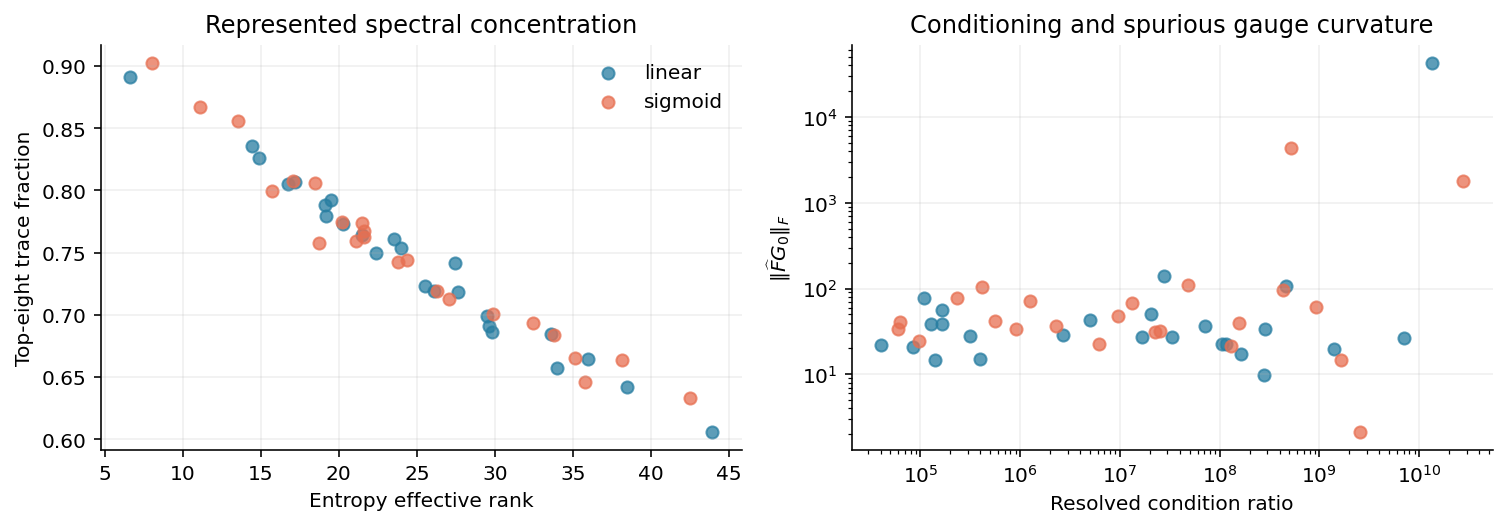

In [ ]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
PROGRESS = Path('/home/evan/Documents/notebooks/amari-chenstov-updates/cache/mnist_experiment/rotated_mnist/plan12_mp_q01_v1/reports/progress.json')
report = json.loads(PROGRESS.read_text(encoding='utf-8'))

# The executed output displays a concise view; the full audit remains in the immutable JSON artifact.
print('Phase 0 keys:', sorted(report['phase0']))


## Fixed-anchor repeated-batch ridge response


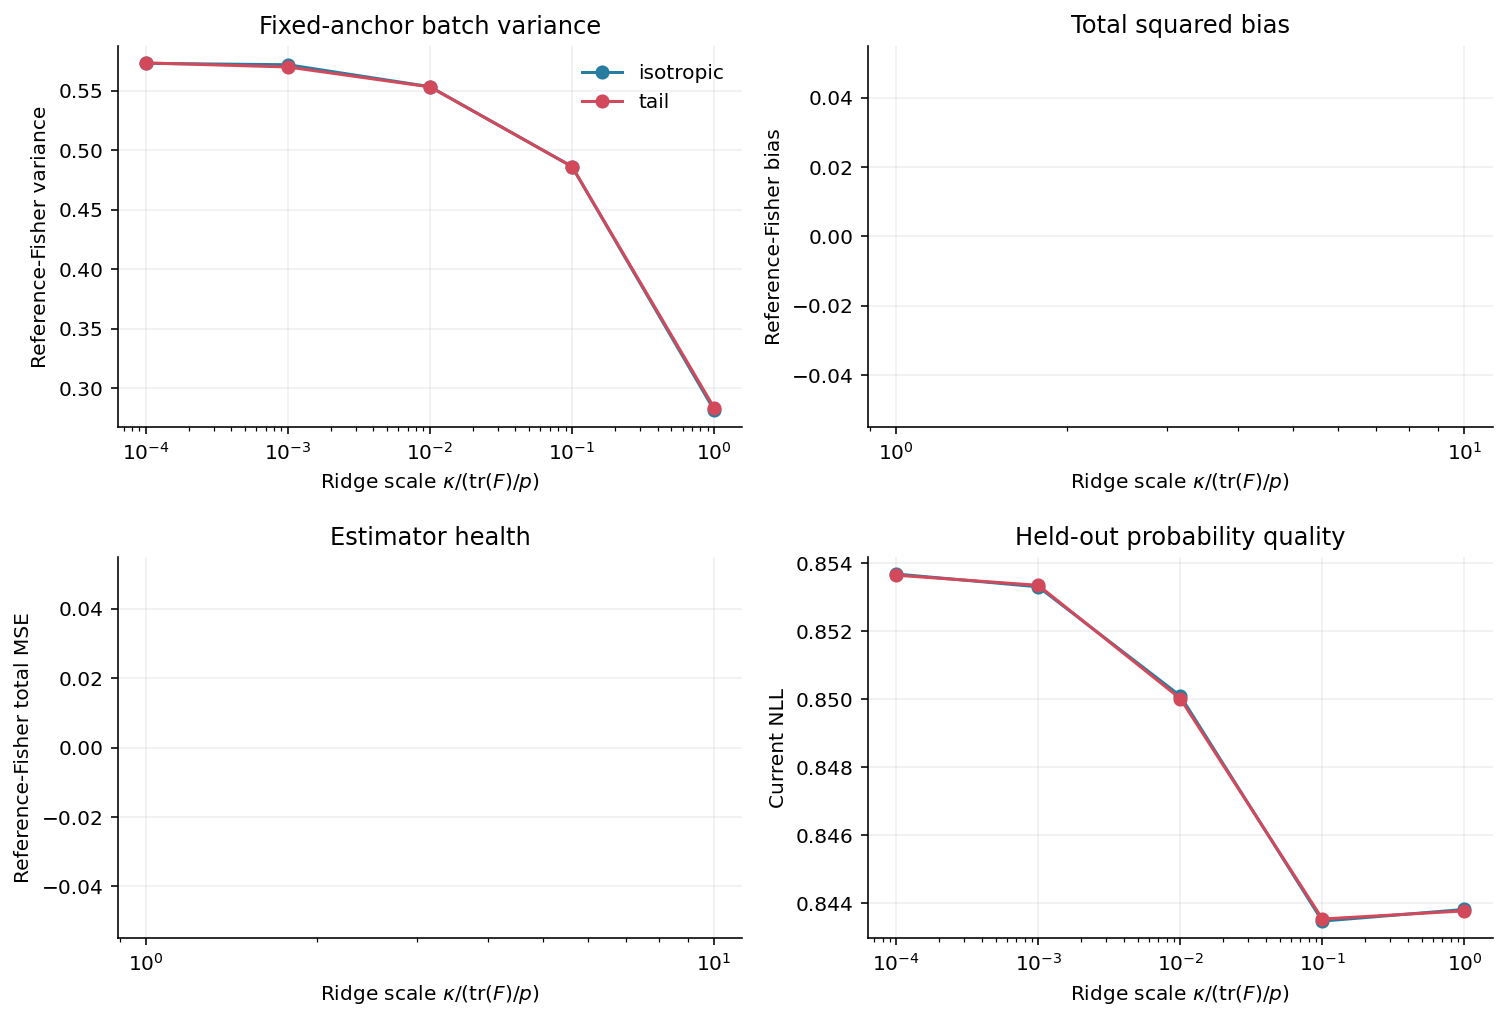

In [ ]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
PROGRESS = Path('/home/evan/Documents/notebooks/amari-chenstov-updates/cache/mnist_experiment/rotated_mnist/plan12_mp_q01_v1/reports/progress.json')
report = json.loads(PROGRESS.read_text(encoding='utf-8'))

# Plot the frozen ridge response after Phase 1 analysis becomes available.
phase1 = report['analyses'].get('phase1_analysis')
print('Phase 1 pending' if phase1 is None else phase1['selection'])


## Propagated estimator health

The propagated conditions differ through $R_t$ in the penalized Fisher $\widehat F_t+\kappa_tR_t$:

$$
\begin{aligned}
\texttt{gauge\_no\_ridge}: \quad
& \kappa_t=0, \\[4pt]
\texttt{isotropic\_ridge}: \quad
& R_t=I, \\[4pt]
\texttt{tail\_ridge}: \quad
& R_t=I-U_{8,t}U_{8,t}^\top, \\[4pt]
\texttt{spectral\_selector}: \quad
& R_t=I, \qquad \kappa_t=41.66\,s_t.
\end{aligned}
$$

Here $s_t=\operatorname{tr}(\widehat F_t)/487$. The `gauge_no_ridge` condition still uses the base Fisher EWC penalty; only its added $\kappa_tR_t$ term is zero.


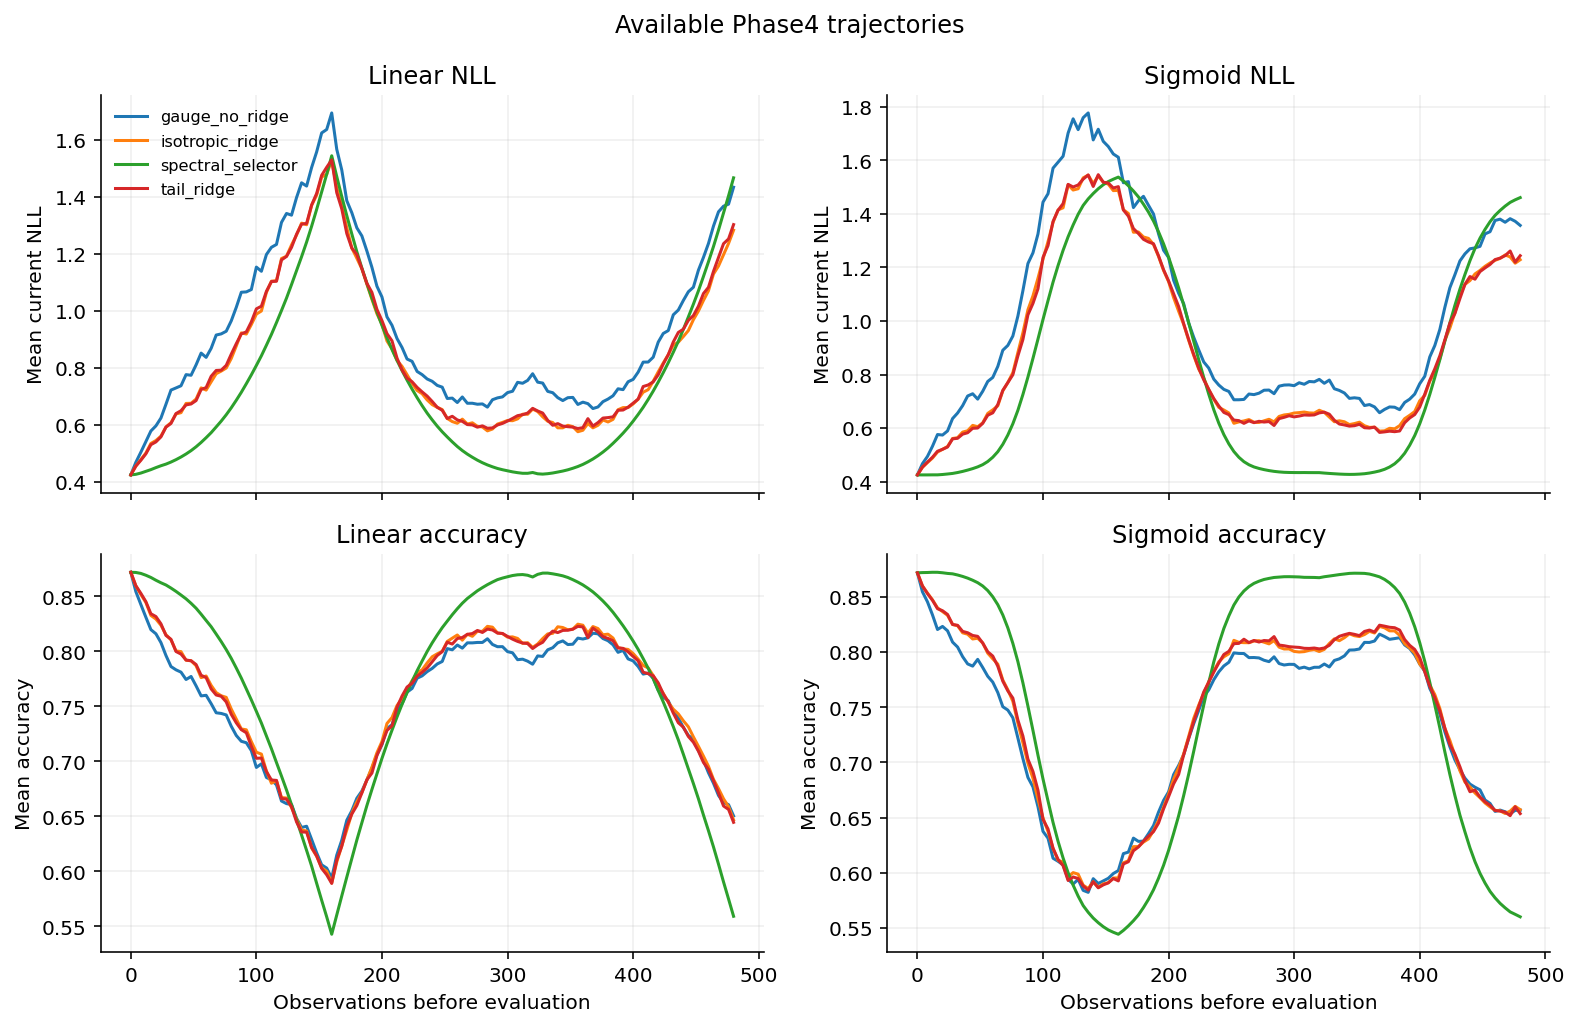

In [ ]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
PROGRESS = Path('/home/evan/Documents/notebooks/amari-chenstov-updates/cache/mnist_experiment/rotated_mnist/plan12_mp_q01_v1/reports/progress.json')
report = json.loads(PROGRESS.read_text(encoding='utf-8'))

# Summaries include only validated completed trajectories.
print(len(report['trajectory_summaries']), 'trajectory artifacts available')


## Spectral calibration and secondary pi diagnostics


{
  "interpretation": "Fresh Phase 4 predictive gains can validate this frozen ridge value as an empirically useful strong-shrinkage condition. They do not retroactively validate the MP calibration mechanism that selected it.",
  "lands_in_useful_region": false,
  "mean_empirical_to_theoretical_ratio": 1.556478999265719,
  "phase1_useful_isotropic_ratio_interval": [
    0.1,
    1.0
  ],
  "phase4_movement_diagnostic": [
    {
      "gauge_no_ridge_mean_total_displacement_squared": 0.17162305688264287,
      "schedule": "linear",
      "spectral_selector_mean_total_displacement_squared": 6.354118222326522e-05,
      "spectral_to_no_ridge_displacement_ratio": 0.00037023686314313327
    },
    {
      "gauge_no_ridge_mean_total_displacement_squared": 0.18536141046995303,
      "schedule": "sigmoid",
      "spectral_selector_mean_total_displacement_squared": 6.340252686159777e-05,
      "spectral_to_no_ridge_displacement_ratio": 0.00034204814637982744
    }
  ],
  "phase4_no_update_contro

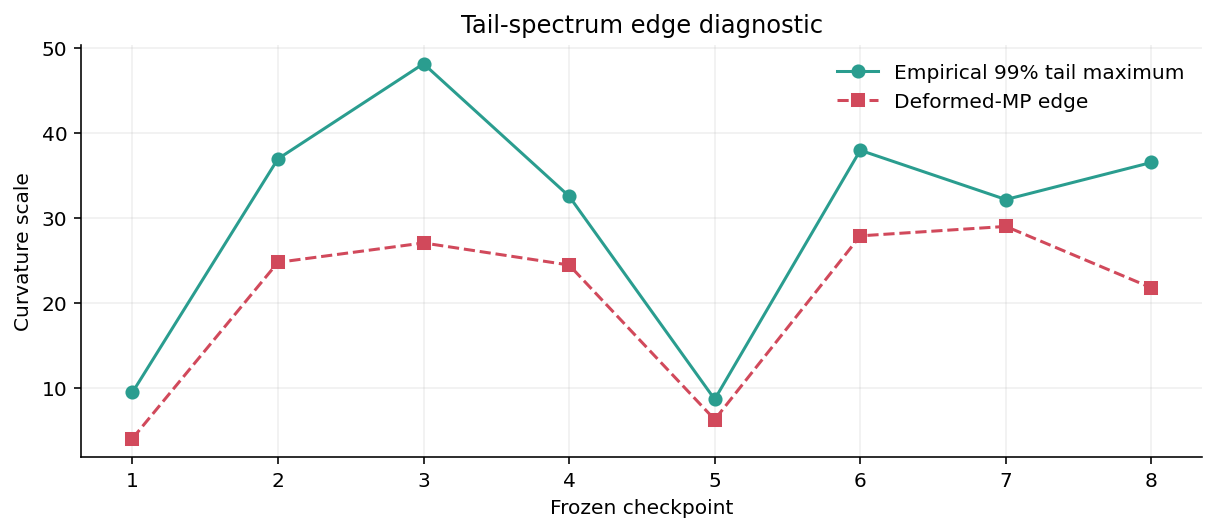

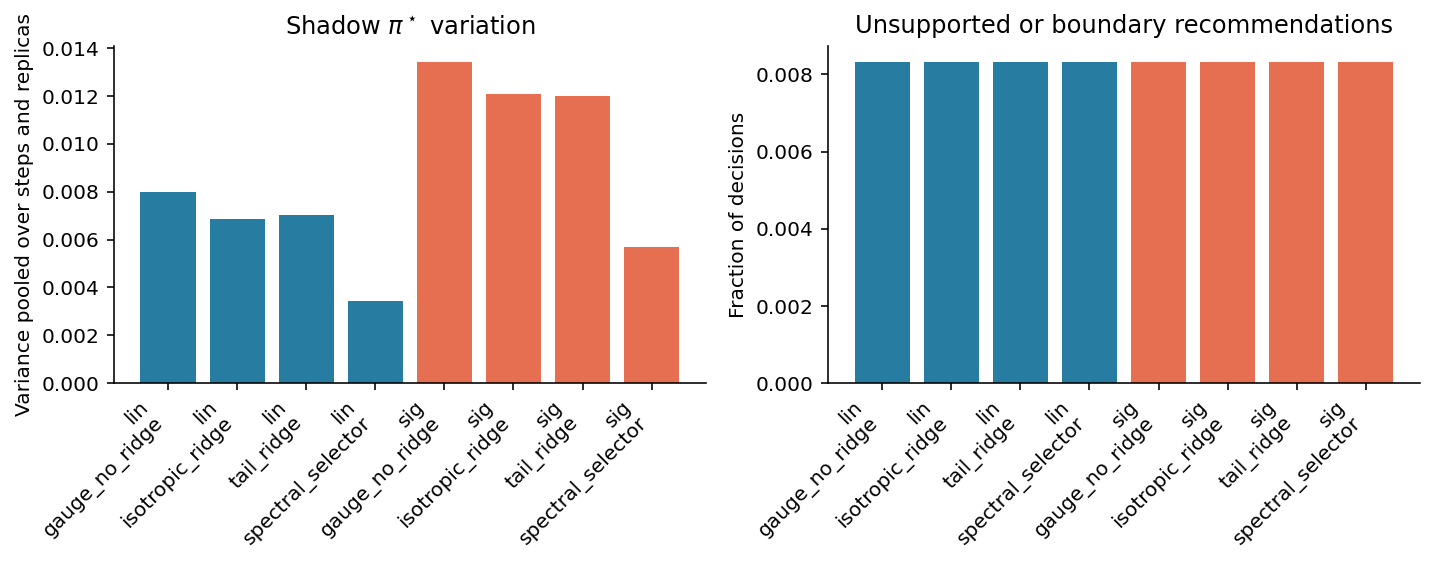

In [ ]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
PROGRESS = Path('/home/evan/Documents/notebooks/amari-chenstov-updates/cache/mnist_experiment/rotated_mnist/plan12_mp_q01_v1/reports/progress.json')
report = json.loads(PROGRESS.read_text(encoding='utf-8'))

phase3 = report['analyses'].get('phase3_analysis')
print('Phase 3 pending' if phase3 is None else phase3['selection'])
print(json.dumps(report.get('phase3_scientific_audit'), indent=2))


## Exploratory MP $q_{.01}$ probe

The archived bootstrap maxima are evaluated with the same `higher` order-statistic convention as $q_{.99}$. The median normalized checkpoint quantile is

$$
\kappa_t/s_t=11.818529434984821.
$$

This isotropic condition is post hoc and descriptive. It asks whether weaker spectral regularization restores adaptation while preserving some retention; it is not a repaired or calibrated selector. Shading shows pointwise $95\%$ normal intervals for the new $q_{.01}$ trajectory mean. Linear and sigmoid remain separate conditions.


This is a post hoc descriptive probe. The 16-replica result measures trajectory health and does not validate the MP selector or support outcome-driven stopping.
Progress: {"linear": 16, "sigmoid": 16}


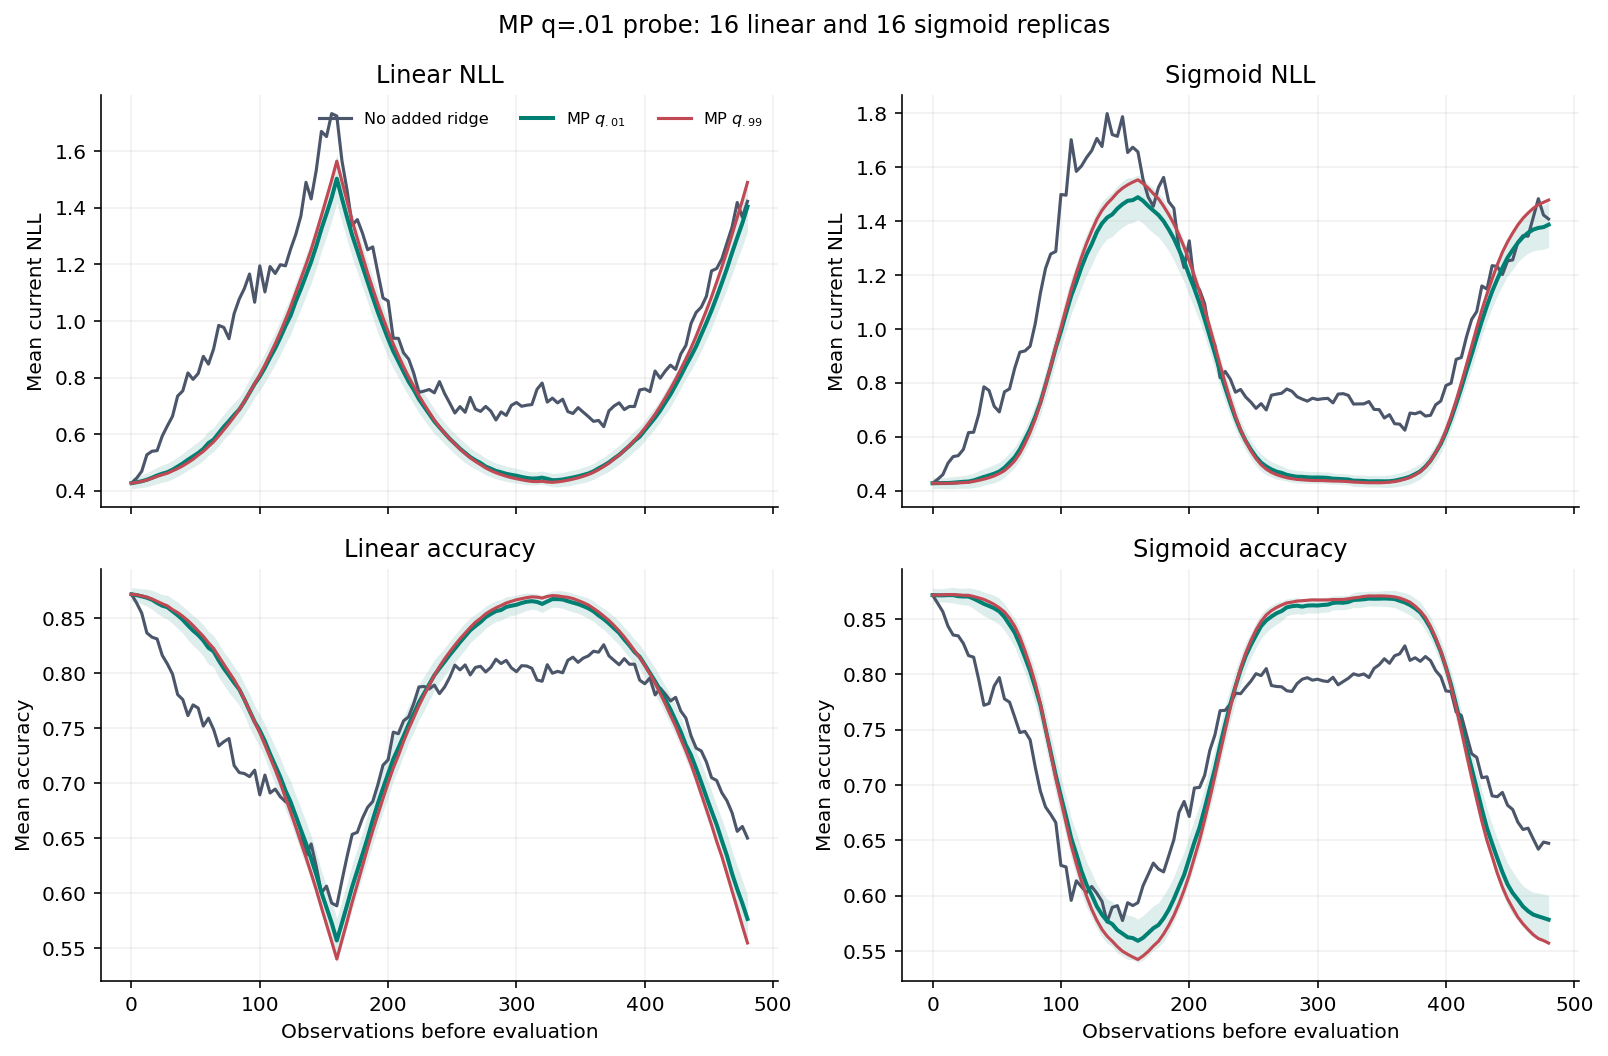

In [ ]:
from pathlib import Path
import json
PROGRESS = Path('/home/evan/Documents/notebooks/amari-chenstov-updates/cache/mnist_experiment/rotated_mnist/plan12_mp_q01_v1/reports/progress.json')
report = json.loads(PROGRESS.read_text(encoding='utf-8'))
probe = report['phase5_probe']

print(probe['interpretation'])
print('Completed replicas:', probe['replicas_completed'])


### Paired trajectory and movement diagnostics

For NLL effects, positive gain means the $q_{.01}$ condition has lower NLL. For accuracy effects, positive gain means higher accuracy. Movement ratios below one indicate less cumulative squared movement than the named control. Intervals remain exploratory.


{
  "interpretation_contract": "Post hoc descriptive probe. Confidence intervals describe paired uncertainty at the frozen 16-replica size and are not selector-calibration or confirmatory claims.",
  "ridge_ratio": 11.818529434984821,
  "schedule_results": [
    {
      "schedule": "linear",
      "optimizer_health": {
        "max_iteration_fraction": 0.0,
        "mean_backtracking_rejections": 0.0,
        "mean_iterations": 11.1171875,
        "mean_relative_final_gradient_norm": 0.001596715489010349
      },
      "fisher_health": {
        "mean_archive_trace": 219.55238392849546,
        "mean_compression_relative_frobenius_error": 0.512650609144804,
        "mean_kappa": 5.320297081895334,
        "mean_tau": 207.49158619391804
      },
      "comparisons": [
        {
          "accuracy_auc_gain": {
            "ci95_high": 0.024199065161140676,
            "ci95_low": 0.013432601505526012,
            "favorable_count": 16,
            "mean": 0.018815833333333344,
         

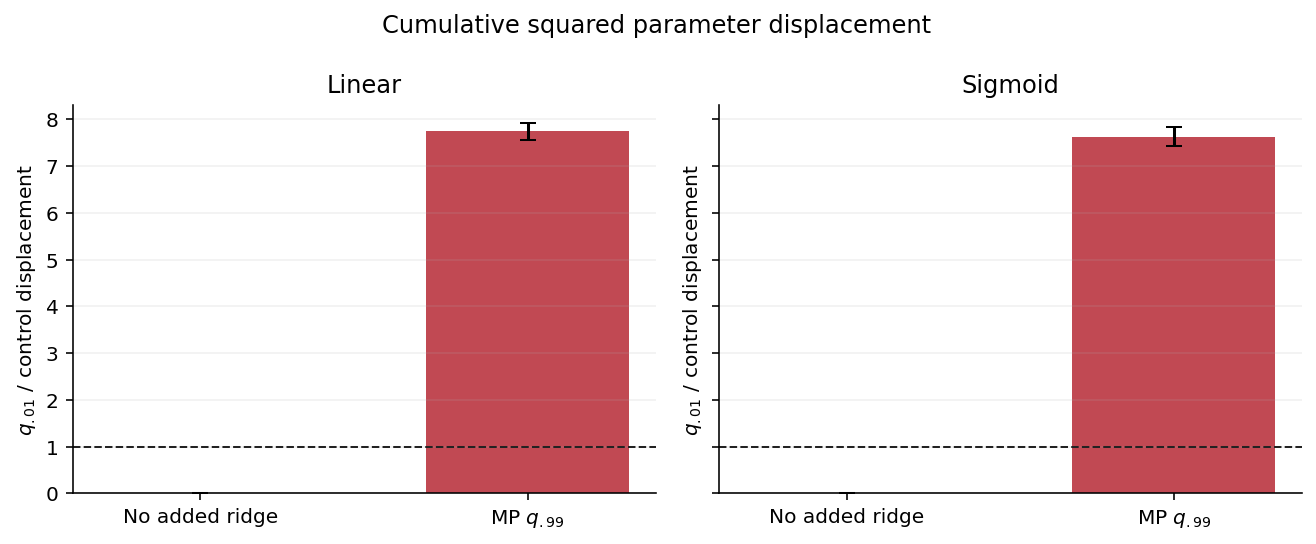

In [ ]:
from pathlib import Path
import json
PROGRESS = Path('/home/evan/Documents/notebooks/amari-chenstov-updates/cache/mnist_experiment/rotated_mnist/plan12_mp_q01_v1/reports/progress.json')
report = json.loads(PROGRESS.read_text(encoding='utf-8'))
probe = report['phase5_probe']

print(json.dumps(probe.get('analysis'), indent=2))


## Conclusion

**Best balance:** `isotropic_ridge` with

$$
\kappa_t=0.1s_t.
$$

| Condition | $30^\circ$ accuracy learned, linear / sigmoid | Upright accuracy change, linear / sigmoid | Movement vs no ridge, linear / sigmoid |
| --- | ---: | ---: | ---: |
| No added ridge | 14.2 pp / 13.9 pp | -11.1 pp / -12.4 pp | 100% / 100% |
| Isotropic $0.1s_t$ | 12.8 pp / 13.7 pp | -10.5 pp / -10.6 pp | 24% / 25% |
| Tail $0.1s_t$ | 12.4 pp / 13.6 pp | -11.3 pp / -11.4 pp | 26% / 25% |
| MP $q_{.01}$ | 6.8 pp / 7.0 pp | -2.3 pp / -2.3 pp | 0.29% / 0.28% |
| MP $q_{.99}$ | 4.7 pp / 4.9 pp | -0.8 pp / -1.0 pp | 0.04% / 0.04% |

Positive $30^\circ$ values measure learning from the common initial model. Negative upright values measure forgetting by the final rotated checkpoint.

The isotropic ridge retained approximately 90% and 99% of no-ridge rotated-accuracy learning under linear and sigmoid schedules. It reduced upright NLL deterioration by approximately 21% and 30%, respectively. Tail ridge showed no reliable advantage, while both MP conditions favored preservation too heavily to be the preferred learning-retention compromise.

The table uses the 16 replicas shared with the post hoc q=.01 probe. It ranks tested conditions rather than identifying an optimal ridge value; the literal no-update control remains absent.


## Interpretation guardrails

Linear and sigmoid schedules are separate experimental conditions. Ridge is assessed through bias, variance, total estimator error, held-out NLL, and retention before any secondary $\pi^\star$ result. Isolated favorable grid points and failed selectors remain visibly labeled. Fresh predictive success at a frozen selector value does not retroactively validate its calibration mechanism.
